# GP-KANの学習安定化方法調査: ベースライン

## 0.背景/目的
本notebookでは、GP-KANの変分ベイズ学習用に、baselineとして以下の設定で学習を行い結果を評価する：
### モデル構成
- **ネットワーク構造**: 2層GP-KAN (入力1次元 → 中間層1次元 → 出力1次元)
- **誘導点数**: 各GPあたり10点
- **GP構成**: (0,0), (1,0) の2つのガウス過程

### 学習パラメータ
- **エポック数**: 400エポック
- **学習率**: 1e-5
- **バッチサイズ**: 32
- **事前学習**: 無効 (pretrain=False)

### 正則化パラメータ
- **global_jitter**: 1e-3
- **baseline_jitter**: 1e-3

In [1]:
JITTER_VALUE = 1e-3  # Jitter項の値

In [2]:
SAVELOAD_PATH = "model_20.pt"

## 1.問題設定

真の関数: フーリエ級数
$$f(t) = \frac{4}{\pi} \sum_{n=1}^{N} \frac{1}{n} \sin(nt), \quad n = 1, 3, 5, \ldots, \quad t \in [0, 1]$$
※$N=15$

データ: 
- 合計1,000件: 学習700件/検証150件/評価150件
- tは$(-1,1)$から一様ランダムサンプリング

モデル:
- 2層のGPKAN: 入力1次元/中間層1次元/出力1次元
    - それぞれのGPを(<1層目のindex>,<2層目のindex>)形式で表すことにすると、GPKANは$(0,0),(1,0)$の2つのGPで構成



## 2.メイン処理
本ノートブックのメイン処理を実行する。実行順は以下の通り：

2-1.データセット作成

2-2.GPKANの学習

2-3.精度評価

2-4.学習中のカーネル行列ランク可視化

### 2-1.データセット作成

In [3]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import sys

sys.path.append("../../")
import japanize_matplotlib
import torch.utils.data
from lib import model as gplib
from lib import runner
from torch.utils.data import DataLoader

In [4]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


# Generate synthetic data with Fourier series function
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
num_samples = 1000

# Generate random input points t from [-1, 1]
t = np.random.uniform(-1, 1, num_samples)


# Compute target values: f(t) = (4/π) * Σ(1/n * sin(nt)) for odd n up to N=15
def fourier_series(t, N=15):
    result = np.zeros_like(t)
    for n in range(1, N + 1, 2):  # odd numbers only: 1, 3, 5, 7, 9, 11, 13, 15
        result += (1 / n) * np.sin(n * t)
    return (4 / np.pi) * result


targets = fourier_series(t, N=15)

# Reshape inputs (t is 1D, but we need it as 2D for compatibility)
inputs = t.reshape(-1, 1)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(inputs)
y_tensor = torch.FloatTensor(targets).reshape(-1, 1)

# Split data into train, validation, and test sets
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データを昇順にソート（X_testとy_testを対応を保ちながら）
sorted_indices = torch.argsort(X_test.squeeze())
X_test = X_test[sorted_indices]
y_test = y_test[sorted_indices]

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create dataloaders
batch_size = 32

In [5]:
# Create dataloaders with reproducible worker processes
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)

Train samples: 700
Validation samples: 150
Test samples: 150


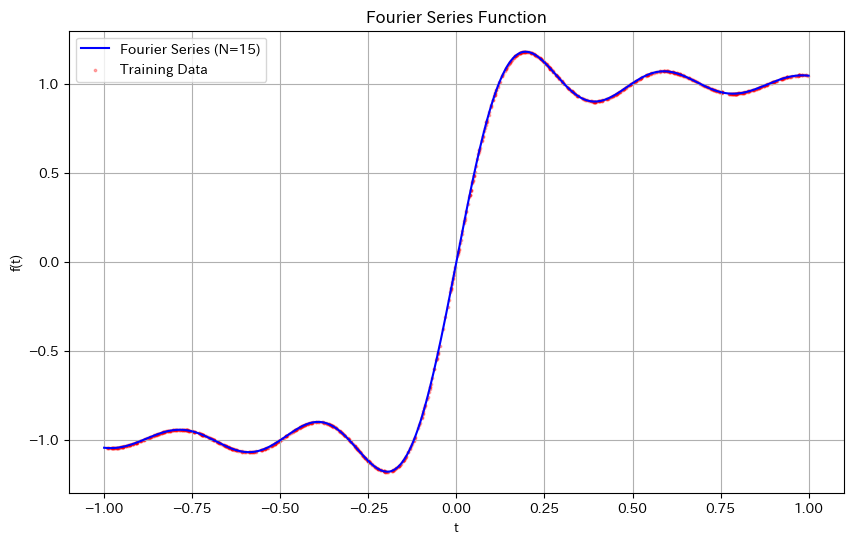

In [6]:
# サンプル数確認
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Fourier級数関数のプロット
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot, "b-", label="Fourier Series (N=15)")
plt.scatter(t, targets, alpha=0.3, s=3, c="red", label="Training Data")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Fourier Series Function")
plt.legend()
plt.grid(True)
plt.show()

### 2-2.モデル学習

In [7]:
num_gp_pts = 10  # Number of Gaussian Process points
model = gplib.GP_Model(
    [
        gplib.LayerFused(1, 1, num_gp_pts),
        gplib.LayerFused(1, 1, num_gp_pts),
    ],
    saveload_path=SAVELOAD_PATH,  # Path to save/load the model
)
np.random.seed(42)  # for reproducibility
torch.manual_seed(42)  # for reproducibility

In [8]:
# 精度評価/可視化関数
def plot_result(model):
    # テストデータでの予測
    with torch.no_grad():
        # バッチごとに予測を行う
        test_predictions = []
        test_targets = []
        test_variances = []

        for X_batch, y_batch in test_dataloader:
            pred = model.predict(X_batch).mean
            var = model.predict(X_batch).var
            test_predictions.append(pred)
            test_variances.append(var)
            test_targets.append(y_batch)

        # 結果を結合
        test_predictions = torch.cat(test_predictions, dim=0)
        test_targets = torch.cat(test_targets, dim=0)
        test_variances = torch.cat(test_variances, dim=0)

    # MSE計算
    mse = torch.mean((test_predictions - test_targets) ** 2)
    rmse = torch.sqrt(mse)

    print(f"Test MSE: {mse.item():.6f}")
    print(f"Test RMSE: {rmse.item():.6f}")

    # 可視化用のデータ準備
    t_test = X_test.numpy().flatten()
    y_test_true = y_test.numpy().flatten()
    y_test_pred = test_predictions.numpy().flatten()

    # 真の関数の連続プロット用
    t_continuous = np.linspace(-1, 1, 500)
    y_continuous = fourier_series(t_continuous, N=15)

    # グラフ作成
    plt.figure(figsize=(12, 8))

    # 真の関数
    plt.plot(
        t_continuous,
        y_continuous,
        "b-",
        linewidth=2,
        label="True Function (Fourier Series)",
        alpha=0.8,
    )

    # テストデータの真値
    plt.scatter(
        t_test,
        y_test_true,
        c="red",
        s=30,
        alpha=0.6,
        label="Test Data (True)",
        marker="o",
    )

    # 予測値
    plt.scatter(
        t_test, y_test_pred, c="green", s=30, alpha=0.6, label="Predictions", marker="x"
    )

    # 予測の不確実性を帯で表示
    lower_bound = y_test_pred - 2 * np.sqrt(test_variances.numpy().flatten())
    upper_bound = y_test_pred + 2 * np.sqrt(test_variances.numpy().flatten())
    plt.fill_between(
        t_test,
        lower_bound,
        upper_bound,
        color="lightgreen",
        alpha=0.3,
        label="Prediction Interval(2σ)",
    )

    plt.xlabel("t")
    plt.ylabel("f(t)")
    plt.title(f"GP-KAN Prediction vs True Function\nTest RMSE: {rmse.item():.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 残差プロット
    plt.figure(figsize=(10, 6))
    residuals = y_test_pred - y_test_true
    plt.scatter(t_test, residuals, c="purple", s=30, alpha=0.6)
    plt.axhline(y=0, color="red", linestyle="--", alpha=0.7)
    plt.xlabel("t")
    plt.ylabel("Residuals (Predicted - True)")
    plt.title("Residual Plot")
    plt.grid(True, alpha=0.3)
    plt.show()

    # 残差の統計情報
    print(f"\nResidual Statistics:")
    print(f"Mean: {np.mean(residuals):.6f}")
    print(f"Std: {np.std(residuals):.6f}")
    print(f"Min: {np.min(residuals):.6f}")
    print(f"Max: {np.max(residuals):.6f}")

    print("plot completed")
    return 0

epoch 0  , train negloglik: 558.40025,    val negloglik: 107.14924    accuracy: 0.5113 lr: [1e-05]
epoch 1  , train negloglik: 98.90657,    val negloglik: 86.26584    accuracy: 0.4021 lr: [9e-06]
epoch 2  , train negloglik: 33.65921,    val negloglik: 24.53038    accuracy: 0.2671 lr: [9e-06]
epoch 3  , train negloglik: 13.47509,    val negloglik: 23.46427    accuracy: 0.2602 lr: [9e-06]
epoch 4  , train negloglik: 9.32127,    val negloglik: 19.87159    accuracy: 0.4079 lr: [9e-06]
epoch 5  , train negloglik: 8.63031,    val negloglik: 22.68173    accuracy: 0.5750 lr: [9e-06]
epoch 6  , train negloglik: 8.00046,    val negloglik: 17.51968    accuracy: 0.3204 lr: [9e-06]
epoch 7  , train negloglik: 6.10758,    val negloglik: 13.61888    accuracy: 0.2865 lr: [9e-06]
epoch 8  , train negloglik: 6.04707,    val negloglik: 13.83727    accuracy: 0.3174 lr: [9e-06]
epoch 9  , train negloglik: 5.20028,    val negloglik: 12.61809    accuracy: 0.2776 lr: [9e-06]
epoch 10 , train negloglik: 5.1593

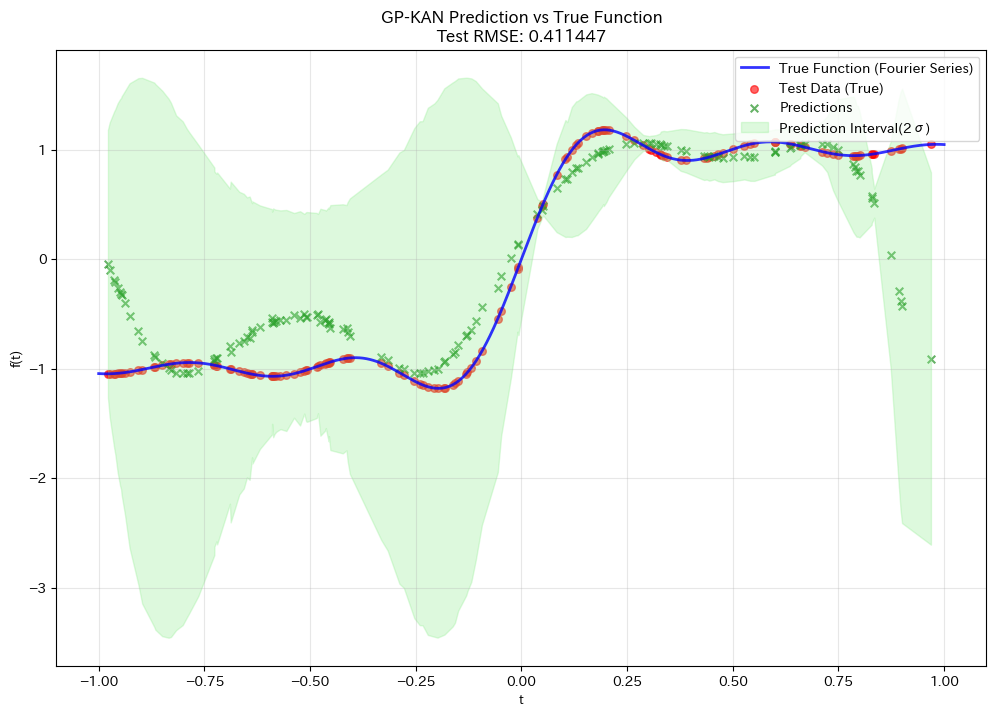

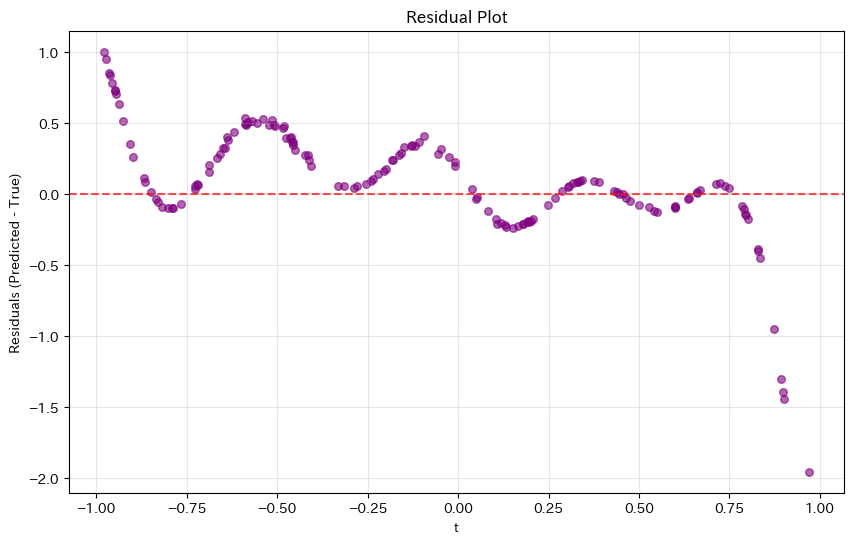


Residual Statistics:
Mean: 0.102578
Std: 0.398455
Min: -1.954281
Max: 1.004120
plot completed

学習時間: 79.63秒 (1.33分)


In [9]:
import time

start_time = time.time()

for epoch in range(1):
    runner.train_model(
        train_dataloader,
        val_dataloader,
        model,
        epochs=200,
        learning_rate=1e-5,
        use_gpu=False,  # True,
        pretrain=False,  # True,
        global_jitter=JITTER_VALUE,
        baseline_jitter=JITTER_VALUE,
    )
    model.save_model()  # optionally save the model after training

    # 可視化
    plot_result(model)

end_time = time.time()
training_time = end_time - start_time

print(f"\n学習時間: {training_time:.2f}秒 ({training_time/60:.2f}分)")

## 3.結果評価
以下の項目に従ってカーネル行列の分析結果をまとめる：

**カーネル行列分析項目**
- 各層のカーネル行列ランクと条件数の分析
- 誘導点の分布と配置の可視化
- カーネル行列のヒートマップ（Jitter項適用前後）
- 固有値分布の分析
- 誘導点間距離の統計的分析

Created output directory: ../outputs
=== 各層の誘導点・予測分布可視化 ===

Layer 0 の可視化を実行中...
✓ Layer 0 の画像を保存: ../outputs/layer_fused0.png

Layer 1 の可視化を実行中...
✓ Layer 0 の画像を保存: ../outputs/layer_fused0.png

Layer 1 の可視化を実行中...
✓ Layer 1 の画像を保存: ../outputs/layer_fused1.png

各層の可視化完了!
✓ Layer 1 の画像を保存: ../outputs/layer_fused1.png

各層の可視化完了!


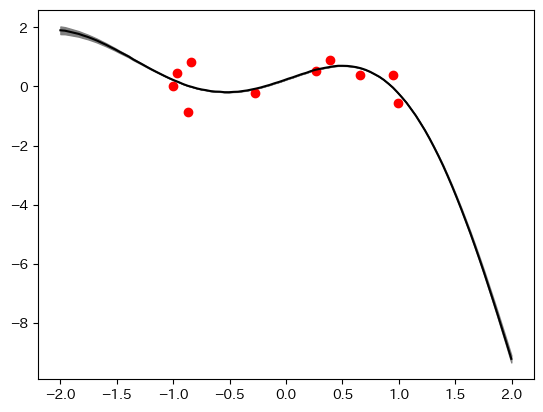

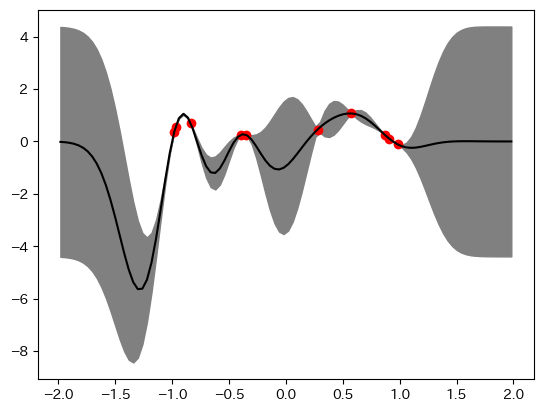

In [12]:
# 出力ディレクトリの作成と各層の可視化
import os

# 出力ディレクトリを作成
output_dir = "../outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")

# 各層の誘導点・予測分布を可視化・保存
print("=== 各層の誘導点・予測分布可視化 ===")

for layer_idx, layer in enumerate(model.layers):
    print(f"\nLayer {layer_idx} の可視化を実行中...")
    
    try:
        # 画像保存を実行
        save_path = f"{output_dir}/layer_fused{layer_idx}.png"
        layer.save_fig(save_path)
        print(f"✓ Layer {layer_idx} の画像を保存: {save_path}")
        
    except Exception as e:
        print(f"✗ Layer {layer_idx} の画像保存に失敗: {e}")
        
        # 代替可視化を実行
        print(f"代替可視化を実行中...")
        
        # 誘導点データを取得
        z_range = layer.get_z().detach()  # 入力値
        h_range = layer.h.detach()  # 出力値
        
        # 基本的な可視化を作成
        plt.figure(figsize=(12, 8))
        
        # 誘導点の分布
        plt.subplot(2, 2, 1)
        plt.scatter(z_range.numpy().flatten(), h_range.numpy().flatten(), 
                   alpha=0.7, s=50, c='blue')
        plt.title(f'Layer {layer_idx}: 誘導点分布')
        plt.xlabel('誘導点位置 (z)')
        plt.ylabel('関数値 (h)')
        plt.grid(True, alpha=0.3)
        
        # 予測分布（テストデータ範囲）
        plt.subplot(2, 2, 2)
        test_x_range = torch.linspace(-1, 1, 100).reshape(-1, 1)
        
        with torch.no_grad():
            # 層ごとの予測を取得
            if layer_idx == 0:
                # 第1層の場合
                pred_dist = layer(test_x_range)
            else:
                # 第2層の場合、前の層の出力を使用
                prev_output = model.layers[0](test_x_range)
                pred_dist = layer(prev_output.mean.reshape(-1, 1))
        
        pred_mean = pred_dist.mean.numpy().flatten()
        pred_std = pred_dist.stddev.numpy().flatten()
        test_x_flat = test_x_range.numpy().flatten()
        
        plt.plot(test_x_flat, pred_mean, 'g-', linewidth=2, label='予測平均')
        plt.fill_between(test_x_flat, 
                        pred_mean - 2*pred_std, 
                        pred_mean + 2*pred_std,
                        alpha=0.3, color='green', label='±2σ 信頼区間')
        plt.scatter(z_range.numpy().flatten(), h_range.numpy().flatten(), 
                   c='red', s=30, alpha=0.7, label='誘導点')
        plt.title(f'Layer {layer_idx}: 予測分布')
        plt.xlabel('入力')
        plt.ylabel('出力')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # パラメータ情報
        plt.subplot(2, 2, 3)
        lengthscale = layer.l.detach().numpy().flatten()
        variance = layer.s.detach().numpy().flatten()
        jitter = layer.get_jitter().detach().numpy().flatten()
        
        params = ['Length Scale', 'Variance', 'Jitter']
        values = [lengthscale[0], variance[0], jitter[0]]
        
        plt.bar(params, values, alpha=0.7)
        plt.title(f'Layer {layer_idx}: パラメータ値')
        plt.ylabel('値')
        plt.yscale('log')
        for i, v in enumerate(values):
            plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')
        
        # 誘導点間距離
        plt.subplot(2, 2, 4)
        z_flat = z_range.numpy().flatten()
        distances = []
        for i in range(len(z_flat)):
            for j in range(i+1, len(z_flat)):
                distances.append(abs(z_flat[i] - z_flat[j]))
        
        plt.hist(distances, bins=15, alpha=0.7, edgecolor='black')
        plt.title(f'Layer {layer_idx}: 誘導点間距離分布')
        plt.xlabel('距離')
        plt.ylabel('頻度')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        alt_save_path = f"{output_dir}/layer_fused{layer_idx}_alternative.png"
        plt.savefig(alt_save_path, dpi=150, bbox_inches='tight')
        
        plt.show()
        print(f"✓ 代替可視化を保存: {alt_save_path}")

print("\n各層の可視化完了!")

=== カーネル行列分析 ===

--- Layer 0 ---
z(誘導点)の範囲: [-1.0000, 0.9971]
h(関数値)の範囲: [-0.8659, 0.8850]
計算開始
計算完了
カーネル行列ランク: 9
条件数: 6.76e+07
最小固有値: -3.24e+00
パラメータ値 - s_ij: -0.7455, l_ij: 0.5077, jitter: 0.0025


/var/folders/3d/x42_xlz13f95zjknk7yll92r0000gn/T/ipykernel_4344/543812989.py:126: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


✓ カーネル行列分析結果を保存: ../outputs/kernel_analysis_layer0.png


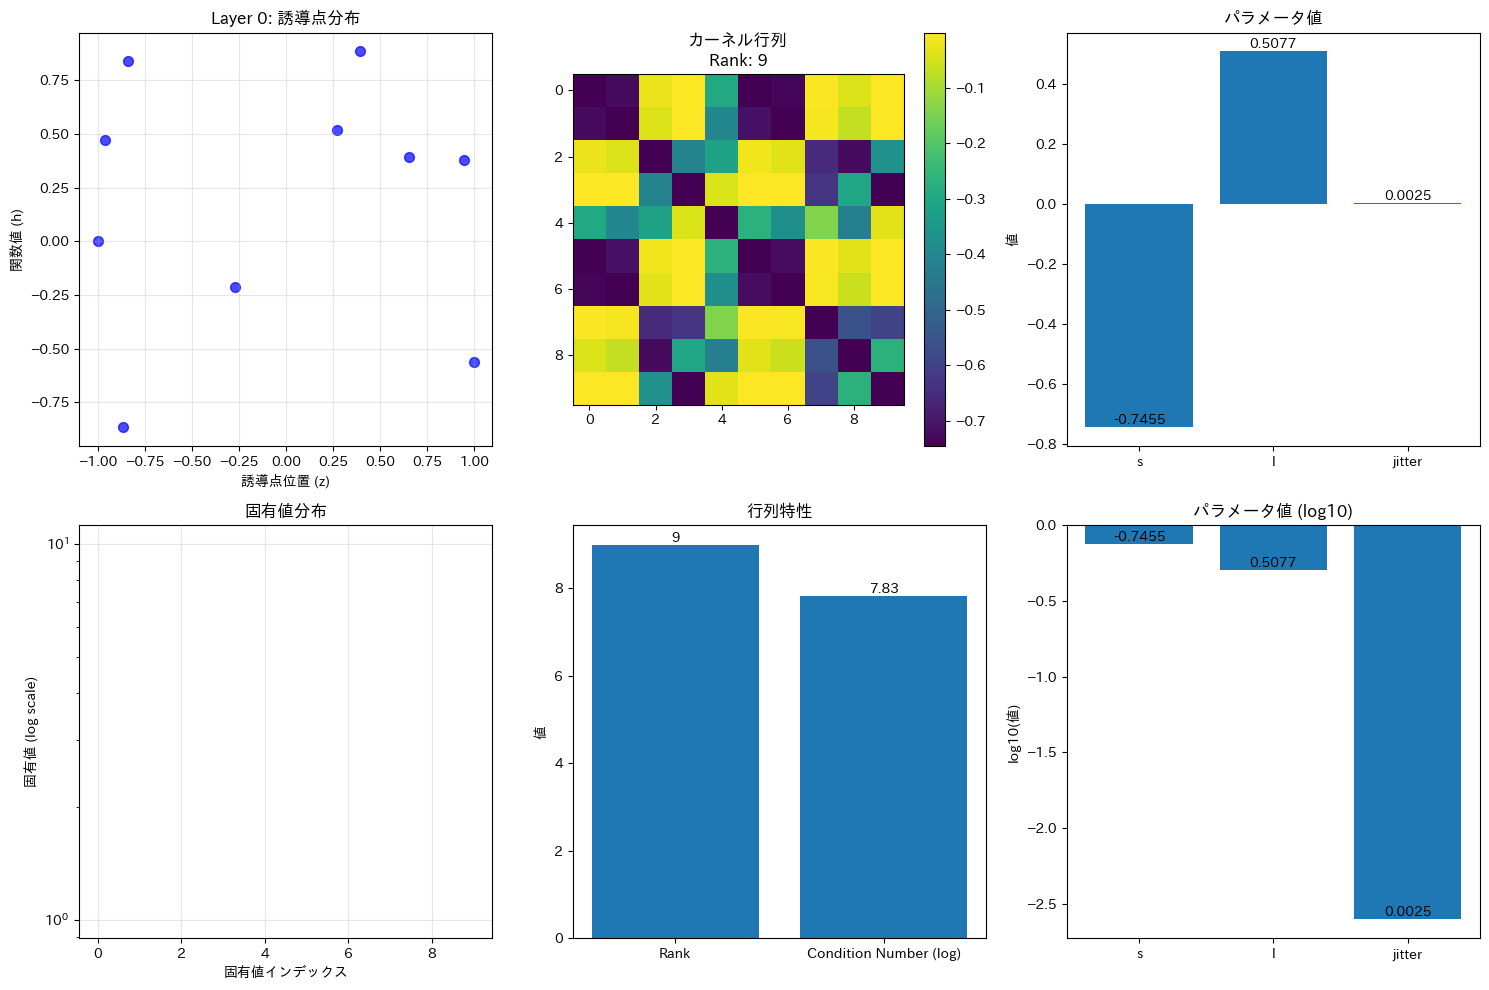

誘導点間距離 - 最小: 0.0301, 最大: 1.9971, 平均: 0.9595
✓ 距離分布分析結果を保存: ../outputs/distance_distribution_layer0.png
✓ 距離分布分析結果を保存: ../outputs/distance_distribution_layer0.png


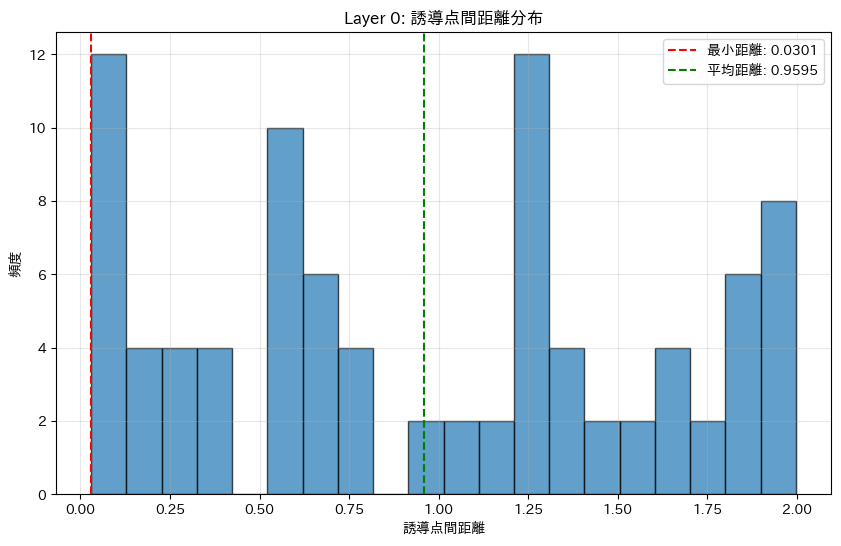


--- Layer 1 ---
z(誘導点)の範囲: [-0.9826, 0.9810]
h(関数値)の範囲: [-0.1088, 1.0691]
計算開始
計算完了
カーネル行列ランク: 4
条件数: 5.67e+09
最小固有値: -5.75e-08
パラメータ値 - s_ij: 0.7385, l_ij: -3.1084, jitter: 0.0021
✓ カーネル行列分析結果を保存: ../outputs/kernel_analysis_layer1.png
✓ カーネル行列分析結果を保存: ../outputs/kernel_analysis_layer1.png


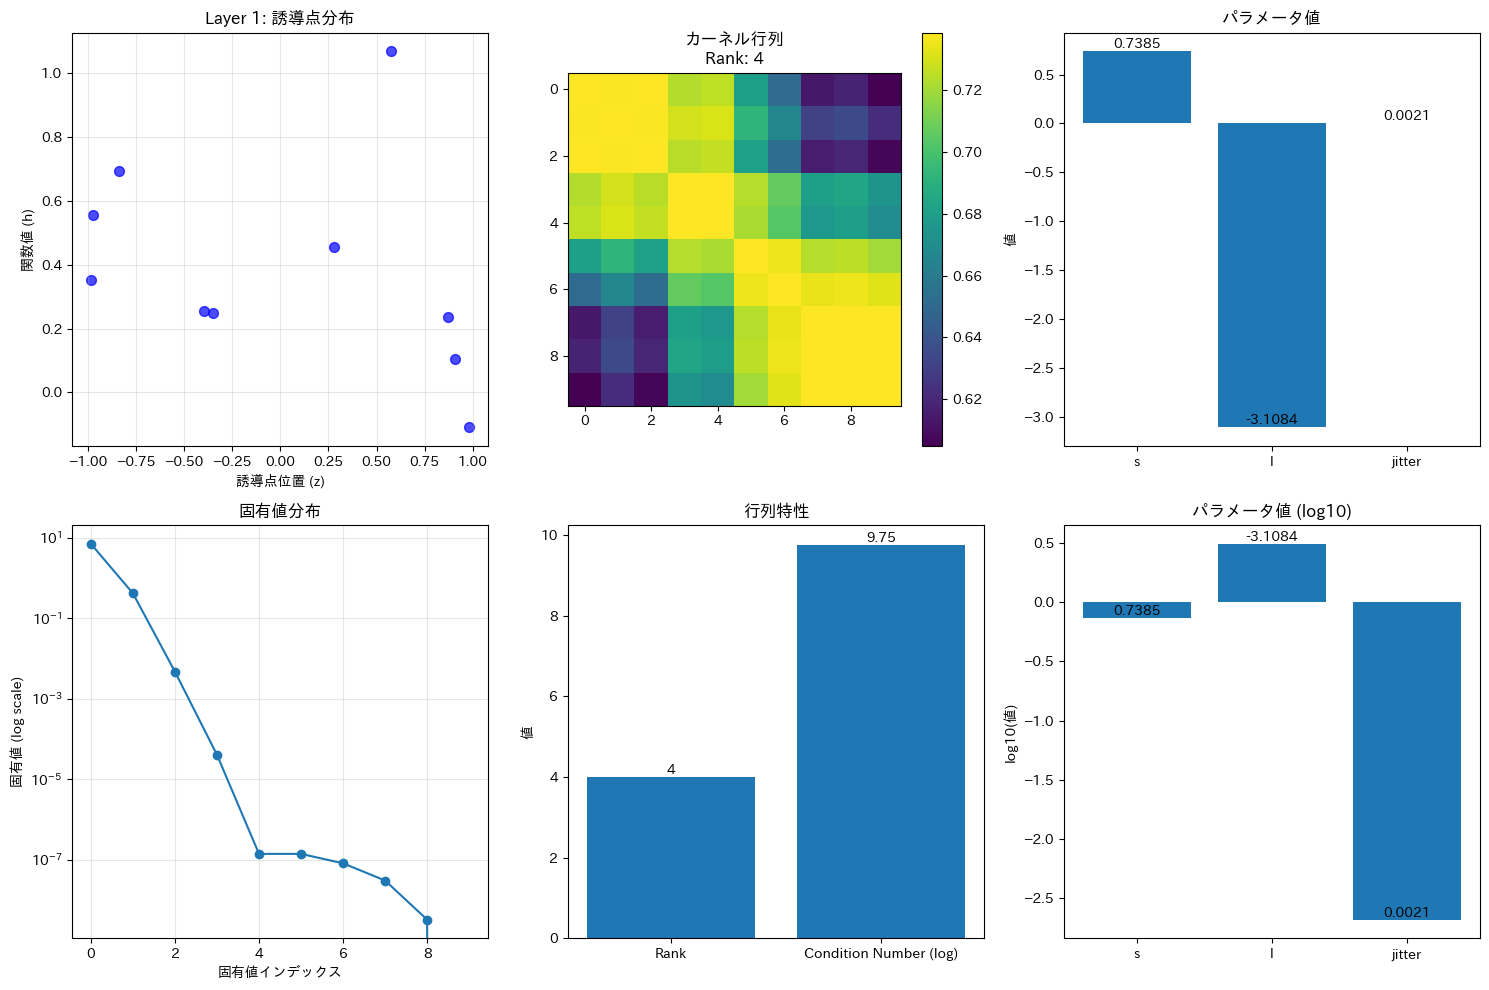

誘導点間距離 - 最小: 0.0128, 最大: 1.9636, 平均: 0.9538
✓ 距離分布分析結果を保存: ../outputs/distance_distribution_layer1.png
✓ 距離分布分析結果を保存: ../outputs/distance_distribution_layer1.png


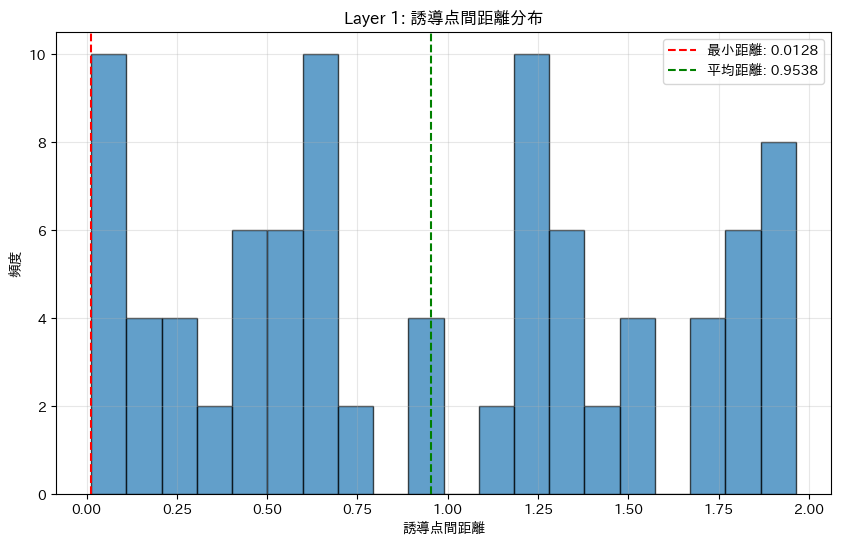

In [13]:
# カーネル行列のランク可視化・分析
import matplotlib.pyplot as plt
import numpy as np
import torch


def analyze_kernel_matrices(model):
    """
    GP-KANの各層のカーネル行列ランクと条件数を分析・可視化する
    """
    print("=== カーネル行列分析 ===")

    # 各層の分析
    for layer_idx, layer in enumerate(model.layers):
        print(f"\n--- Layer {layer_idx} ---")

        # 誘導点を取得
        z_range = layer.get_z().detach()  # 入力値
        h_range = layer.h.detach()  # 出力値
        jitter = layer.get_jitter().detach()  # Shape: [1, 1]
        print(
            f"z(誘導点)の範囲: [{z_range.min().item():.4f}, {z_range.max().item():.4f}]"
        )
        print(
            f"h(関数値)の範囲: [{h_range.min().item():.4f}, {h_range.max().item():.4f}]"
        )

        # カーネル行列を計算
        with torch.no_grad():
            # カーネル行列を計算
            lengthscale = layer.l.detach()  # Shape: [1, 1]
            variance = layer.s.detach()  # Shape: [1, 1]

            # Set i=j=1 for processing (assuming we want the first GP component)
            i, j = 0, 0  # Using 0-based indexing for tensor access

            # Get parameters for this specific GP
            z_ij = z_range[i, j, :]  # Shape: [X]
            l_ij = lengthscale[i, j]  # Scalar
            s_ij = variance[i, j]  # Scalar

            # Reshape inducing points for distance computation
            z_ij = z_ij.unsqueeze(1)  # Shape: [X, 1]

            # Compute kernel matrix for this GP
            pairwise_sq_dists = torch.cdist(z_ij, z_ij, p=2) ** 2
            # 誘導点間のカーネル行列
            K = s_ij * torch.exp(-pairwise_sq_dists / (2 * l_ij**2))

            print("計算開始")
            # ランク計算
            rank_clean = torch.linalg.matrix_rank(K)

            # 条件数計算
            cond_clean = torch.linalg.cond(K)

            # 固有値
            eigenvals_clean = torch.linalg.eigvals(K).real

            print("計算完了")

            print(f"カーネル行列ランク: {rank_clean.item()}")
            print(f"条件数: {cond_clean.item():.2e}")
            print(f"最小固有値: {eigenvals_clean.min().item():.2e}")
            print(
                f"パラメータ値 - s_ij: {s_ij.item():.4f}, l_ij: {l_ij.item():.4f}, jitter: {jitter.item():.4f}"
            )

        # 可視化
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # 誘導点の分布
        axes[0, 0].scatter(
            z_range.numpy().flatten(),
            h_range.numpy().flatten(),
            alpha=0.7,
            s=50,
            c='blue'
        )
        axes[0, 0].set_title(f"Layer {layer_idx}: 誘導点分布")
        axes[0, 0].set_xlabel("誘導点位置 (z)")
        axes[0, 0].set_ylabel("関数値 (h)")
        axes[0, 0].grid(True, alpha=0.3)

        # カーネル行列のヒートマップ
        im1 = axes[0, 1].imshow(K.numpy(), cmap="viridis")
        axes[0, 1].set_title(f"カーネル行列\nRank: {rank_clean.item()}")
        plt.colorbar(im1, ax=axes[0, 1])

        # パラメータ値のプロット
        params = ["s", "l", "jitter"]
        values = [s_ij.item(), l_ij.item(), jitter.item()]
        axes[0, 2].bar(params, values)
        axes[0, 2].set_title("パラメータ値")
        axes[0, 2].set_ylabel("値")
        for i, v in enumerate(values):
            axes[0, 2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

        # 固有値分布
        eigenvals_sorted = torch.sort(eigenvals_clean, descending=True)[0]
        axes[1, 0].semilogy(eigenvals_sorted.numpy(), "o-")
        axes[1, 0].set_title("固有値分布")
        axes[1, 0].set_xlabel("固有値インデックス")
        axes[1, 0].set_ylabel("固有値 (log scale)")
        axes[1, 0].grid(True, alpha=0.3)

        # 条件数とランクの可視化
        metrics = ["Rank", "Condition Number (log)"]
        metric_values = [rank_clean.item(), np.log10(cond_clean.item())]
        axes[1, 1].bar(metrics, metric_values)
        axes[1, 1].set_title("行列特性")
        axes[1, 1].set_ylabel("値")
        for i, v in enumerate(metric_values):
            if i == 0:
                axes[1, 1].text(i, v, f"{int(v)}", ha="center", va="bottom")
            else:
                axes[1, 1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

        # パラメータ値の詳細プロット（対数スケール）
        axes[1, 2].bar(params, np.log10(np.abs(values)))
        axes[1, 2].set_title("パラメータ値 (log10)")
        axes[1, 2].set_ylabel("log10(値)")
        for i, v in enumerate(values):
            axes[1, 2].text(i, np.log10(abs(v)), f"{v:.4f}", ha="center", va="bottom")

        plt.tight_layout()
        
        # 分析結果を保存
        analysis_save_path = f"{output_dir}/kernel_analysis_layer{layer_idx}.png"
        plt.savefig(analysis_save_path, dpi=150, bbox_inches='tight')
        print(f"✓ カーネル行列分析結果を保存: {analysis_save_path}")
        plt.show()

        # 誘導点間の距離分析
        distances = torch.cdist(z_ij.unsqueeze(0), z_ij.unsqueeze(0)).squeeze(
            0
        )  # Shape: [X, X]
        min_dist = distances[distances > 0].min()
        max_dist = distances[distances > 0].max()
        mean_dist = distances[distances > 0].mean()

        print(
            f"誘導点間距離 - 最小: {min_dist.item():.4f}, 最大: {max_dist.item():.4f}, 平均: {mean_dist.item():.4f}"
        )

        # 距離分布のヒストグラム
        plt.figure(figsize=(10, 6))
        dist_flat = distances[distances > 0].numpy()
        plt.hist(dist_flat, bins=20, alpha=0.7, edgecolor="black")
        plt.axvline(
            min_dist.item(),
            color="red",
            linestyle="--",
            label=f"最小距離: {min_dist.item():.4f}",
        )
        plt.axvline(
            mean_dist.item(),
            color="green",
            linestyle="--",
            label=f"平均距離: {mean_dist.item():.4f}",
        )
        plt.xlabel("誘導点間距離")
        plt.ylabel("頻度")
        plt.title(f"Layer {layer_idx}: 誘導点間距離分布")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 距離分布結果を保存
        distance_save_path = f"{output_dir}/distance_distribution_layer{layer_idx}.png"
        plt.savefig(distance_save_path, dpi=150, bbox_inches='tight')
        print(f"✓ 距離分布分析結果を保存: {distance_save_path}")
        plt.show()


# 実行
analyze_kernel_matrices(model)

In [14]:
# 保存された画像ファイルの確認
import glob

print("=== 保存された可視化ファイル一覧 ===")
output_files = glob.glob(f"{output_dir}/*.png")
if output_files:
    for file_path in sorted(output_files):
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"✓ {os.path.basename(file_path)} ({file_size:.1f} KB)")
else:
    print("保存された画像ファイルが見つかりませんでした。")

print(f"\n出力ディレクトリ: {os.path.abspath(output_dir)}")
print(f"総ファイル数: {len(output_files)}")

# 分析結果サマリー
print("\n" + "="*60)
print("カーネル行列分析・可視化完了!")
print("="*60)
print("✅ 各層の誘導点分布可視化")
print("✅ カーネル行列ランク・条件数分析") 
print("✅ 固有値分布分析")
print("✅ 誘導点間距離統計分析")
print("✅ 全結果の画像保存")
print("="*60)

=== 保存された可視化ファイル一覧 ===
✓ distance_distribution_layer0.png (41.3 KB)
✓ distance_distribution_layer1.png (40.6 KB)
✓ kernel_analysis_layer0.png (123.9 KB)
✓ kernel_analysis_layer1.png (138.6 KB)
✓ layer_fused0.png (16.4 KB)
✓ layer_fused1.png (23.9 KB)

出力ディレクトリ: /Users/daisuke.takehara/Desktop/workdir_gpkan/gp-kan/demo/outputs
総ファイル数: 6

カーネル行列分析・可視化完了!
✅ 各層の誘導点分布可視化
✅ カーネル行列ランク・条件数分析
✅ 固有値分布分析
✅ 誘導点間距離統計分析
✅ 全結果の画像保存
